In [ ]:
# Imports Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

print('Libraries Uploaded Successfully')

Libraries Uploaded Successfully


In [ ]:
# Loads Dataset

df = pd.read_csv('credit_card_fraud_10k.csv')
display(df)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [ ]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
# Drop transaction_id Column
df = df.drop(columns='transaction_id')

In [ ]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


## **Exploratory** **Data** **Analysis**  (EDA)

In [ ]:
df.isnull().sum()

,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Fraude Rate is: 1.51


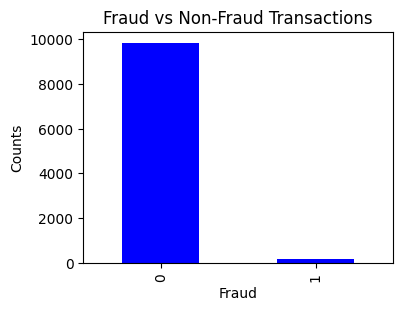

In [ ]:
fraud_class = df['is_fraud'].value_counts()
fraud_rate = df['is_fraud'].mean() * 100

print(f'Fraude Rate is: {fraud_rate}')

plt.figure(figsize=(4,3))
fraud_class.plot(kind='bar', color='blue')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud')
plt.ylabel('Counts')
plt.show()



The Target Variable is highly Imbalanced, With only 151 fraud cases (1.51%) out of 9849 (98.49%). This shows fraudelent Transactions are very rare in this dataset.
Which will cause the model predict non fraud mostly , and can ignore the fraudelent transactions.
Now First we will build a baseline model like a logistic regression, and after then we will use imbalance techniqes like class_weights and SMOTE .

# **Numerical Feature** **Distribution**

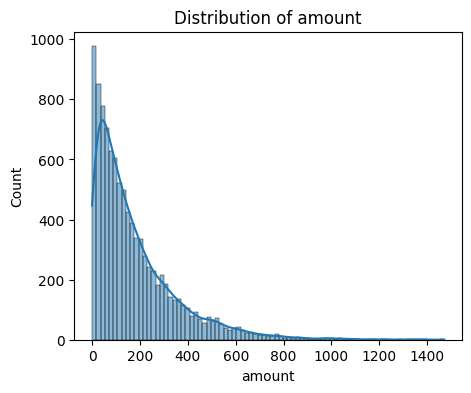

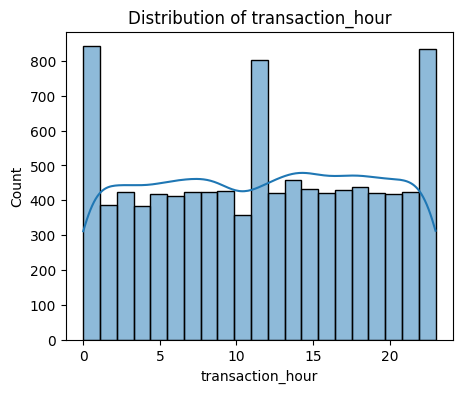

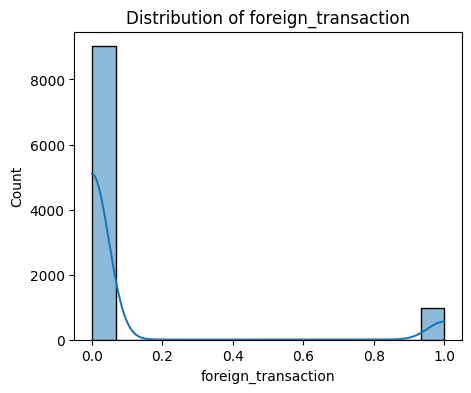

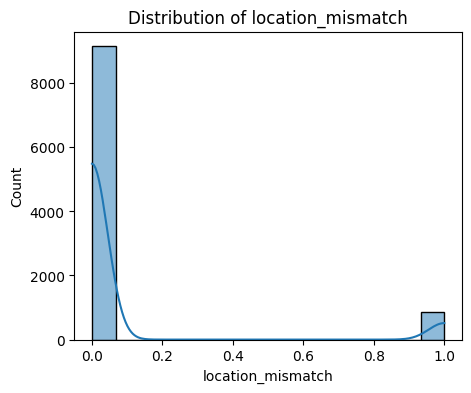

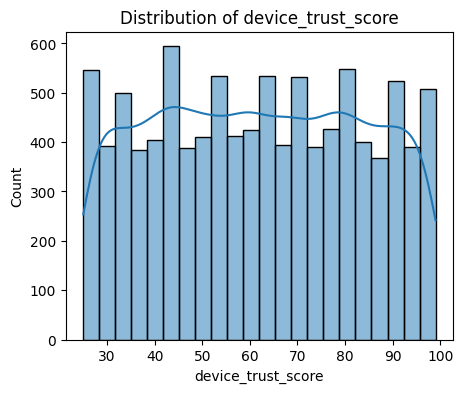

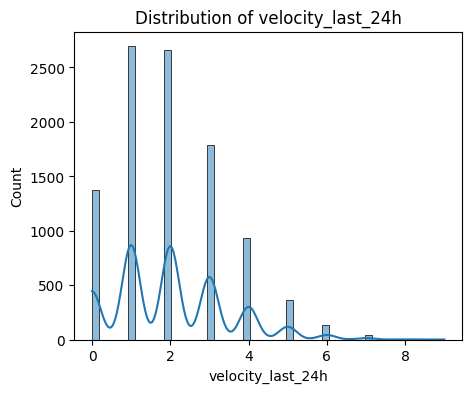

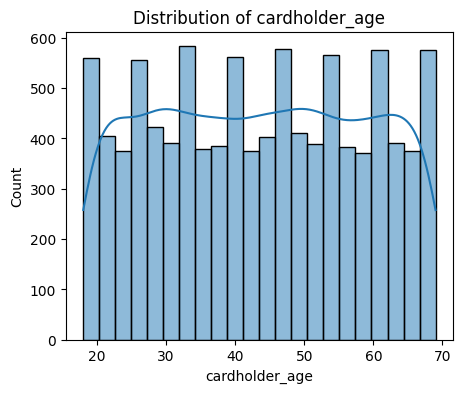

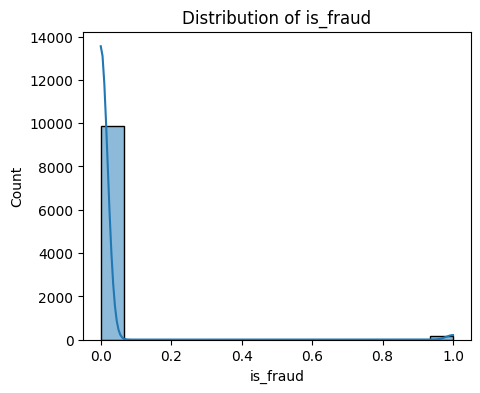

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
  plt.figure(figsize = (5,4))
  sns.histplot(df[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()


# **Outliers** **Detection**

In [ ]:
outlier_cols = ['amount', 'velocity_last_24h']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    percentage = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} outliers, Percentage : {percentage:.2f}")


amount: 501 outliers, Percentage : 5.01
velocity_last_24h: 51 outliers, Percentage : 0.51


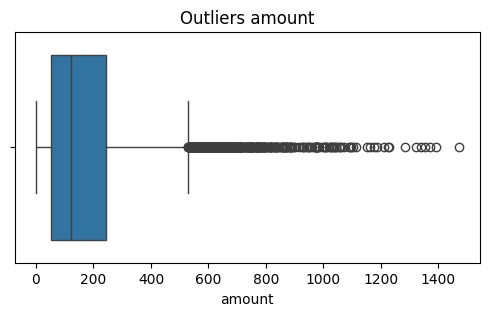

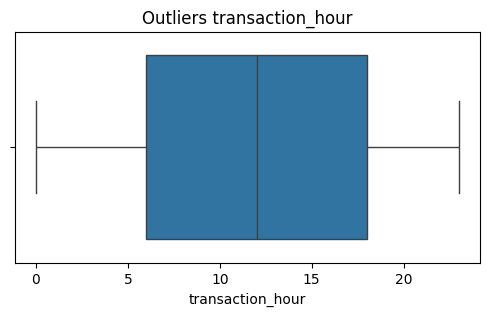

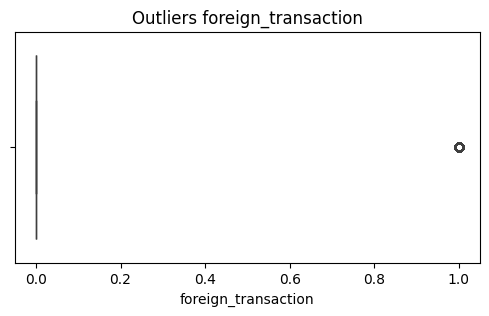

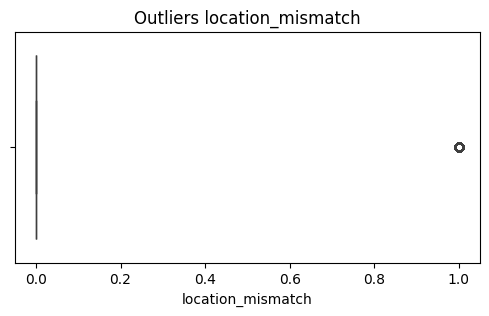

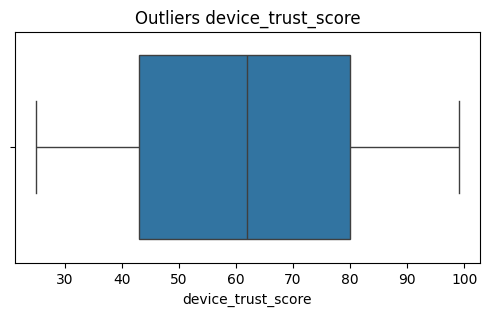

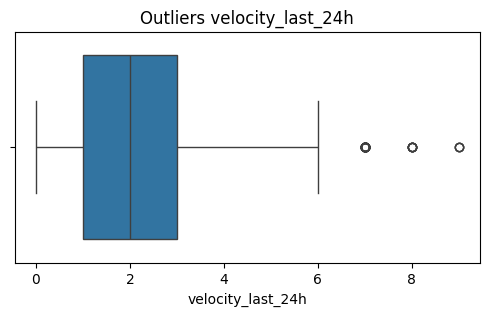

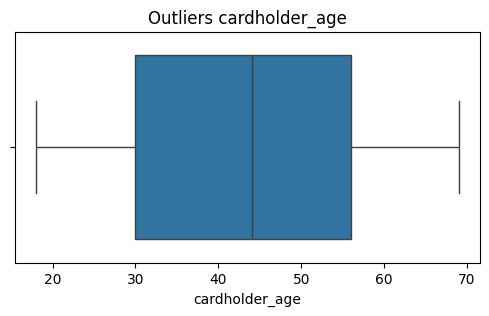

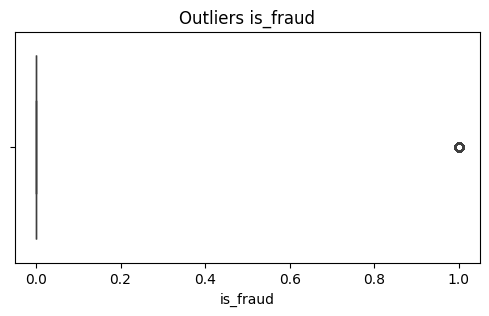

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
  plt.figure(figsize=(6,3))
  sns.boxplot(x= df[col])
  plt.title(f'Outliers {col}')
  plt.show()

## Distribution and Outlier Analysis

My Observation After Plotting Histograms and Boxplots.

`amount` and `velocity_last_24h` showed right-skewed distributions with extreme values.

 I'll use Transformation `log1p()`  to reduce skewness and compress outlier, In preprocessing.

Boxplot and IQR analysis identified significant outliers mainly in:

   `amount`
   `velocity_last_24h`

  These will be handled during preprocessing after train-test splitting.

# **Feature** **Selection**

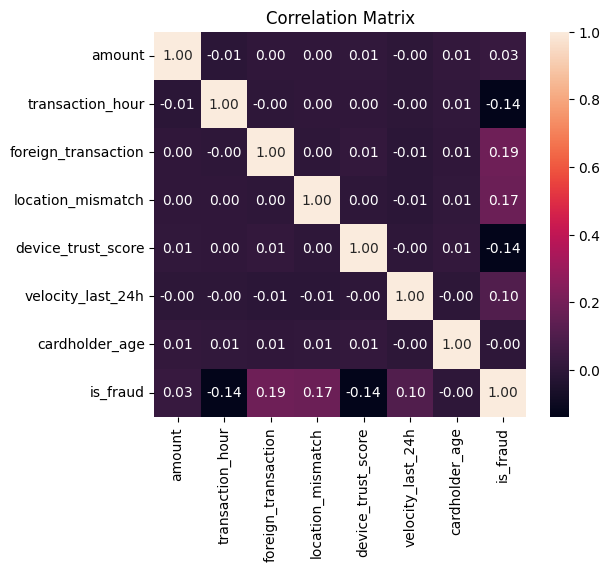

In [ ]:
# First find Correlation between numeric cols
corr_matrix = df.corr(numeric_only= True)

# Plot Heatmap to see correlation Matrix
plt.figure(figsize = (6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

### Correlation Analysis

I analyzed the correlation heatmap and found that all features have weak linear relationships with the target variable (`is_fraud`). The highest correlations were observed for `foreign_transaction` (0.19) and `location_mismatch` (0.17), though these values are still relatively low.

This is expected in fraud detection problems, where patterns are often non-linear and cannot be fully captured by Pearson correlation.

I also found no  multicollinearity. Therefore, all features were retained for model training.

#  **Cross** **Tab** **(Categorical data)**

In [ ]:
cross_tab  = pd.crosstab(df['is_fraud'], df['merchant_category'])
display(cross_tab)

merchant_category,Clothing,Electronics,Food,Grocery,Travel
is_fraud,,,,,
0,2026,1899,2058,1905,1961
1,24,24,35,39,29


### Merchant Category vs Fraud Analysis

I analyzed the relationship between `merchant_category` and the target variable (`is_fraud`) using a crosstab. Fraudulent transactions, with Grocery showing the highest fraud rate and Clothing the lowest.


# **Train &** **Test Split**

 The dataset must split into training and testing sets before applying preprocessing techniques.

  This prevents **data leakage** by ensuring that transformations are learned only from the training data.

  Techniques such as scaling calculate parameters (mean and standard deviation), so they are fitted on the training set and only applied to the test set using `transform()`.
  
   This ensures the test data remains unseen during training and provides a reliable evaluation of model performance.


In [ ]:
# Seperate Features and Target

x = df.drop(columns='is_fraud') # Features
y = df['is_fraud'] # Target


In [ ]:

print(x.shape)
print(y.shape)

(10000, 8)
(10000,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2, # 80% Training Data 20% Testing Data
    random_state=42, # Randomly selection of data
    stratify=y     # Maintain the class balance
    )


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 8)
(2000, 8)
(8000,)
(2000,)


# **Data**  **Pre-processing**

In [ ]:
# Encoding only for merchang_category

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoder.fit(x_train[['merchant_category']])

x_train_encoded = encoder.transform(x_train[['merchant_category']])
x_test_encoded = encoder.transform(x_test[['merchant_category']])




`amount` and `velocity_last_24h` showed right-skewed distributions during analysis, which can affect model performance.

I will apply log1p transformation to reduce skewness and compress extreme values.
Unlike scaling, which only adjusts the range of values, log transformation changes the distribution shape.

After log transformation, scaling will be applied to bring numerical features into a comparable range.


In [ ]:
# Transformation Log1p : Reduce skewness and compress extreme values unlike scaling which only compress the outliers.

x_train['amount'] = np.log1p(x_train['amount'])
x_test['amount'] = np.log1p(x_test['amount'])

x_train['velocity_last_24h'] = np.log1p(x_train['velocity_last_24h'])
x_test['velocity_last_24h']  = np.log1p(x_test['velocity_last_24h'])


In [ ]:
# Scaling

scaler = StandardScaler()

scaler.fit(x_train[['amount',
             'velocity_last_24h',
             'cardholder_age',
             'transaction_hour',
             'device_trust_score']])
x_train_scaled = scaler.transform(x_train[['amount',
             'velocity_last_24h',
             'cardholder_age',
             'transaction_hour',
             'device_trust_score']])
x_test_scaled = scaler.transform(x_test[['amount',
             'velocity_last_24h',
             'cardholder_age',
             'transaction_hour',
             'device_trust_score']])




In [ ]:
binary_cols = [
    'foreign_transaction',
    'location_mismatch'
]

x_train_binary = x_train[binary_cols]
x_test_binary = x_test[binary_cols]

In [ ]:
# Combine Scaled,Encoded,binary cols togather using np.hstack()

x_train_processed = np.hstack((x_train_encoded,
                               x_train_scaled,
                               x_train_binary))

x_test_processed  = np.hstack((x_test_encoded,
                               x_test_scaled,
                               x_test_binary))

In [ ]:
print(f'x_train_processed', {x_train_processed.shape})
print(f'x_test_processed' ,{x_test_processed.shape})


x_train_processed {(8000, 12)}
x_test_processed {(2000, 12)}


# **Model Training**

In [ ]:
# Baseline Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state = 42)
model.fit(x_train_processed,y_train)  # Train model


LogisticRegression(random_state=42)

In [ ]:
y_pred = model.predict(x_test_processed) # Make Prediction on Unseen Data


# **Evaluate baseline model**

In [ ]:
from sklearn.metrics import accuracy_score # Accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.992


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test,y_pred)

print(f'Confusion Matrix :\n {conf_matrix}')
print(f'\n\nClassification Report :\n {class_report}')

Confusion Matrix :
 [[1969    1]
 [  15   15]]


Classification Report :
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.94      0.50      0.65        30

    accuracy                           0.99      2000
   macro avg       0.96      0.75      0.82      2000
weighted avg       0.99      0.99      0.99      2000



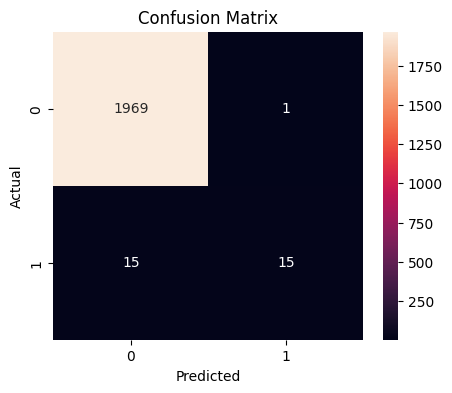

In [ ]:
plt.figure(figsize = (5,4))
sns.heatmap(conf_matrix,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Baseline Model is Quite Strong, with 94% precision and 0.65 f1score ,
But the biggest issue is with Recall: 50% , which means It catches only 50% of all fraud transactions.

The dataset was highly imbalanced, with fraud transactions representing only a small percentage of the data. This class imbalance likely contributed to the model achieving a recall of 50%, meaning that half of the fraud cases were missed. To improve the model's ability to detect fraud transactions, I will apply the `class_weight='balanced'` technique and evaluate whether it improves recall and overall fraud detection performance.


In [ ]:


balanced_model= LogisticRegression(
    class_weight='balanced',
    random_state=42
)

In [ ]:
balanced_model.fit(
    x_train_processed,
    y_train
)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
y_pred_balanced = balanced_model.predict(
    x_test_processed
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

print(f'Accuracy: {accuracy_score(y_test,y_pred_balanced)}')
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.9295
[[1829  141]
 [   0   30]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1970
           1       0.18      1.00      0.30        30

    accuracy                           0.93      2000
   macro avg       0.59      0.96      0.63      2000
weighted avg       0.99      0.93      0.95      2000



In [ ]:
pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_processed,
    y_train
)

In [ ]:
# Train  Model On SMOTE Data

smote_model = LogisticRegression(
    random_state=42
)
smote_model.fit(
    x_train_smote,
    y_train_smote
    )


LogisticRegression(random_state=42)

In [ ]:
# Make prediction

y_pred_smote = smote_model.predict(
    x_test_processed
)


In [ ]:
accuracy = accuracy_score(y_test, y_pred_smote)
class_report = classification_report(y_test, y_pred_smote)
conf_matrix = confusion_matrix(y_test,y_pred_smote)

print(f'Accuracy: {accuracy}')
print(f'\n\nConfusion Matrix :\n {conf_matrix}')
print(f'\n\nClassification Report :\n {class_report}')


Accuracy: 0.9395


Confusion Matrix :
 [[1849  121]
 [   0   30]]


Classification Report :
               precision    recall  f1-score   support

           0       1.00      0.94      0.97      1970
           1       0.20      1.00      0.33        30

    accuracy                           0.94      2000
   macro avg       0.60      0.97      0.65      2000
weighted avg       0.99      0.94      0.96      2000



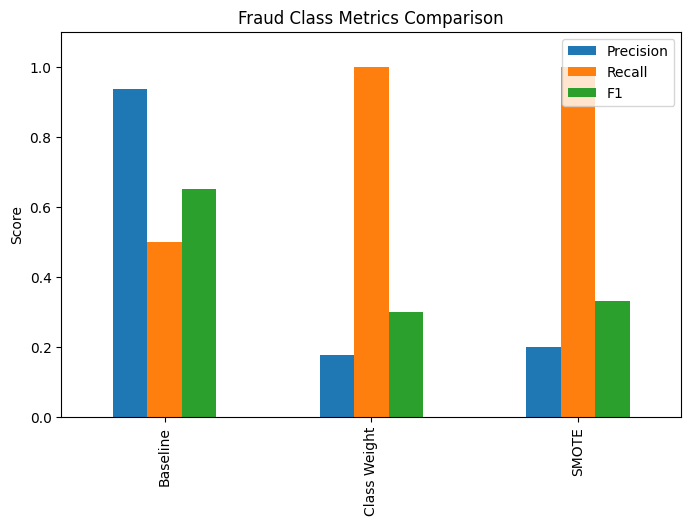

In [ ]:
# Compares Imbalancing Techniques

baseline = classification_report(y_test, y_pred, output_dict=True)
class_weight = classification_report(y_test, y_pred_balanced, output_dict=True)
smote = classification_report(y_test, y_pred_smote, output_dict=True)

df = pd.DataFrame({
    'Baseline': [
        baseline['1']['precision'],
        baseline['1']['recall'],
        baseline['1']['f1-score']
    ],
    'Class Weight': [
        class_weight['1']['precision'],
        class_weight['1']['recall'],
        class_weight['1']['f1-score']
    ],
    'SMOTE': [
        smote['1']['precision'],
        smote['1']['recall'],
        smote['1']['f1-score']
    ]
}, index=['Precision', 'Recall', 'F1'])

df.T.plot(kind='bar', figsize=(8,5))
plt.title('Fraud Class Metrics Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.show()

Logistic Regression provided a strong baseline with high accuracy (99.2%) and precision (94%). However, due to class imbalance, it detected only 50% of fraud transactions. Applying Class Weight and SMOTE increased recall to 100%, all fraud cases were identified. But this improvement introduced many false positives, significantly reducing precision. This experiment highlights the tradeoff between fraud detection and false alarms when working with imbalanced datasets